# [Evaluations](https://wikidocs.net/259203)

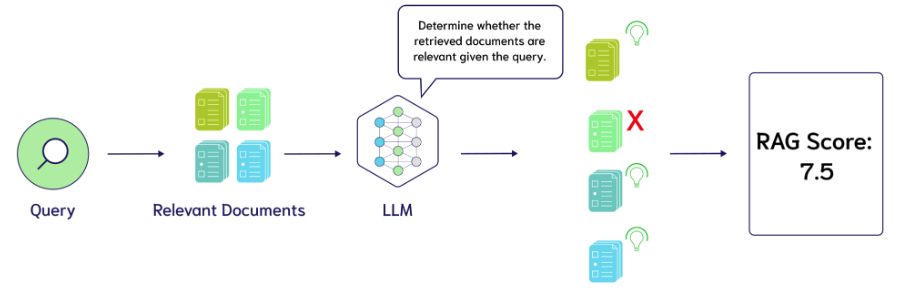

## Evaluation Score
- `Faithfulness`: 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다.
- `Relevancy`: 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다.
- `Context Precision`: contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- `Context recall`: 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.

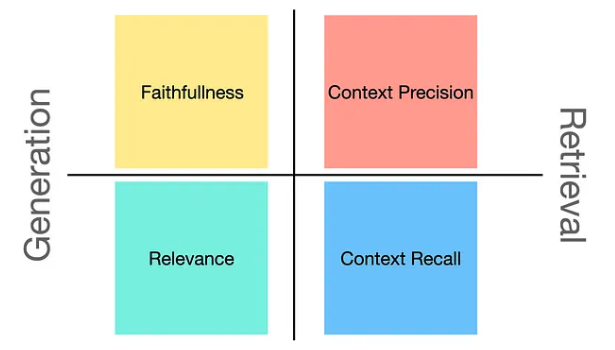

### Generation Metrics

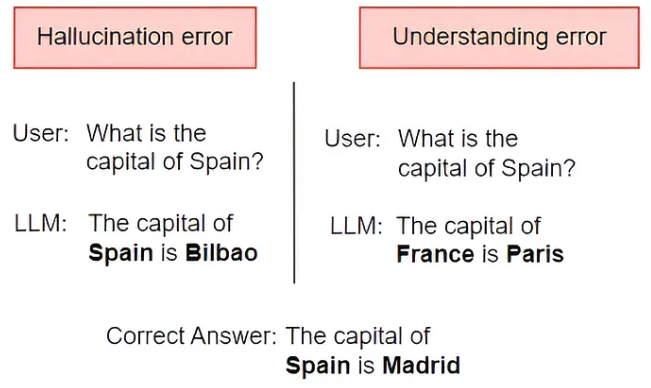

#### Answer Relevancy

- Answer Relevancy는 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다. 이 지표의 주요 특징과 계산 방법을 요약하면 다음과 같습니다:
  - `목적`: 생성된 답변의 관련성을 평가합니다.
  - `점수 해석`: 낮은 점수는 불완전하거나 중복 정보를 포함한 답변을, 높은 점수는 더 나은 관련성을 나타냅니다.
  - `계산에 사용되는 요소`: question, context, answer

- Answer Relevancy의 계산 방법: - 원래 question과 answer를 기반으로 생성된 인공적인 질문들 간의 평균 코사인 유사도로 정의됩니다.
  - $E_{g_i}$는 생성된 질문 $i$의 임베딩
  - $E_o$는 원래 질문의 임베딩
  - $N$은 생성된 질문의 수 (기본값 3)
$$
answer\; relevancy = { 1 \over N } \sum{cos(E_{g_i},\; E_{o})}
$$
또는
$$
answer\; relevancy = { 1 \over N } \sum{{ E_{g_i}E_{o} \over |E_{g_i}||E_{o}| }}
$$

- 주의사항: 실제로는 점수가 대부분 0과 1 사이에 있지만, 코사인 유사도의 특성상 수학적으로 -1에서 1 사이의 값을 가질 수 있습니다.
- 이 지표는 질문-답변 시스템의 성능을 평가하는 데 유용하며, 특히 생성된 답변이 원래 질문의 의도를 얼마나 잘 반영하는지를 측정합니다.


#### Faithfulness

- Faithfulness는 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다. 주요 특징은 다음과 같습니다:
  - `목적`: 답변의 사실적 일관성을 컨텍스트와 비교하여 평가합니다.
  - `계산 요소`: 답변과 검색된 컨텍스트를 사용합니다.
  - `점수 범위`: 0에서 1 사이로 조정되며, 높을수록 더 좋습니다.

- Faithfulness 점수 계산 방법:

$$
Faithfulness\; score = { |Number\; of\; claims\; in\; the\; generated\; answer\; that\; can\; be\; inferred\; from\; given\; context| \over |Total\; number\; of\; claims\; in\; the\; generated\; answer| }
$$

- 계산 과정:
  1. 생성된 답변에서 주장(claims)들을 식별합니다.
  2. 각 주장을 주어진 컨텍스트와 대조 검증하여 컨텍스트에서 추론 가능한지 확인합니다.
  3. 위 수식을 사용하여 점수를 계산합니다.

- 예시
  - `질문`: "아인슈타인은 어디서, 언제 태어났나요?"
  - `컨텍스트`: "알버트 아인슈타인(1879년 3월 14일 출생)은 독일 출신의 이론 물리학자로, 역사상 가장 위대하고 영향력 있는 과학자 중 한 명으로 여겨집니다."
  - `높은 충실도 답변`: "아인슈타인은 1879년 3월 14일 독일에서 태어났습니다."
  - `낮은 충실도 답변`: "아인슈타인은 1879년 3월 20일 독일에서 태어났습니다."

### [Retrieval Metrics](https://www.pinecone.io/learn/series/vector-databases-in-production-for-busy-engineers/rag-evaluation/)

#### Context Precision(Precision@k)
- Context Precision은 contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- 이상적으로는 모든 관련 chunks가 상위 순위에 나타나야 합니다.
- 이 지표는 question, ground_truth, 그리고 contexts를 사용하여 계산되며, 0에서 1 사이의 값을 가집니다.
- 높은 점수일수록 더 나은 정밀도를 나타냅니다.

$$
Precision@k = { true\; positives@k \over (true\; positives@k) + (false\; positives@k) }
$$

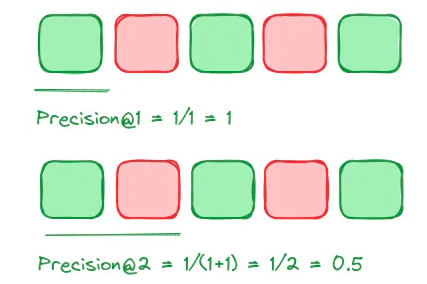

#### Context Recall(Recall@k)
- Context recall은 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.
- 이는 question, ground truth 및 검색된 context를 사용하여 계산되며, 값은 0에서 1 사이로, 높을수록 더 나은 성능을 나타냅니다.
- Ground truth 답변에서 context recall을 추정하기 위해, ground truth 답변의 각 주장이 검색된 context에 귀속될 수 있는지 분석됩니다. 이상적인 시나리오에서는 ground truth 답변의 모든 주장이 검색된 context에 귀속될 수 있어야 합니다.

$$
Recall@k = { true\; positives@k \over (true\; positives@k) + (false\; negatives@k) }
$$

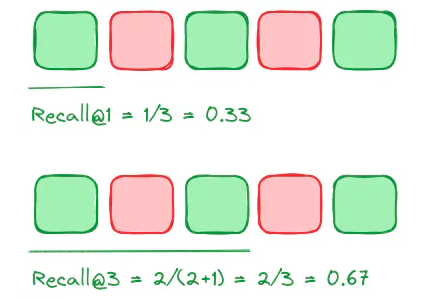

# [RAGAs - Evaluations](https://docs.ragas.io/en/stable/)

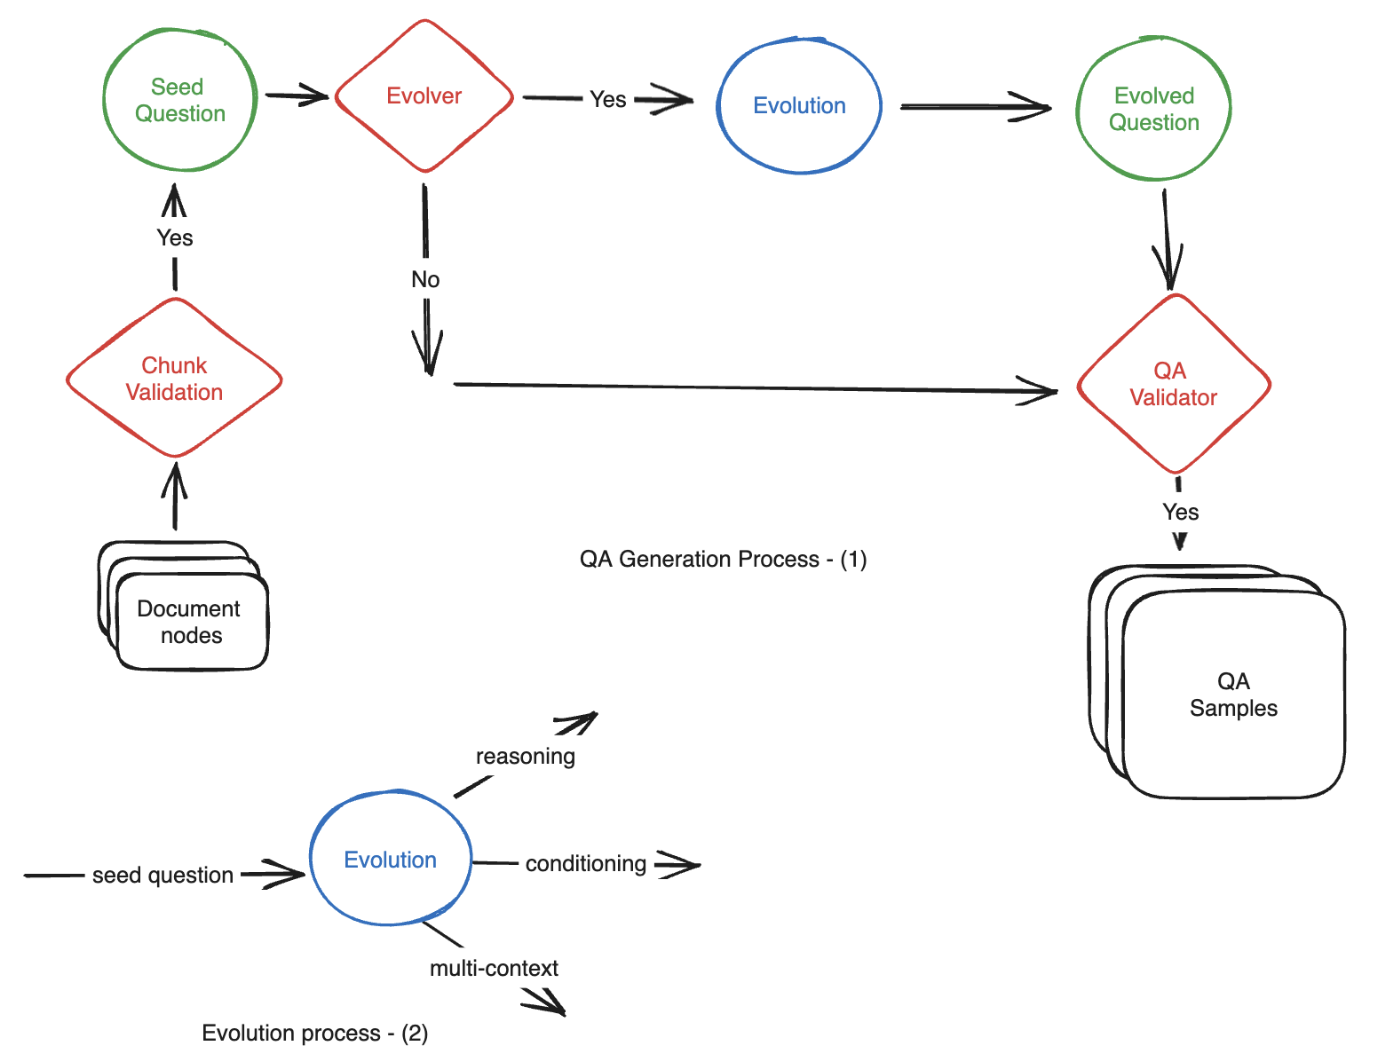

## [평가 데이터셋 생성](https://docs.ragas.io/en/latest/getstarted/testset_generation.html)

### 문서 전처리

In [1]:
from langchain_community.document_loaders import PDFPlumberLoader

# 문서 로더 생성
DATA_PATH = "./data/"
loader = PDFPlumberLoader(DATA_PATH+"SPRI_AI_Brief_2023년12월호_F.pdf")

# 문서 로딩
documents = loader.load()

In [2]:
print(f"PDF 페이지 수: {len(documents)}")

PDF 페이지 수: 23


> PDF 파일 내용

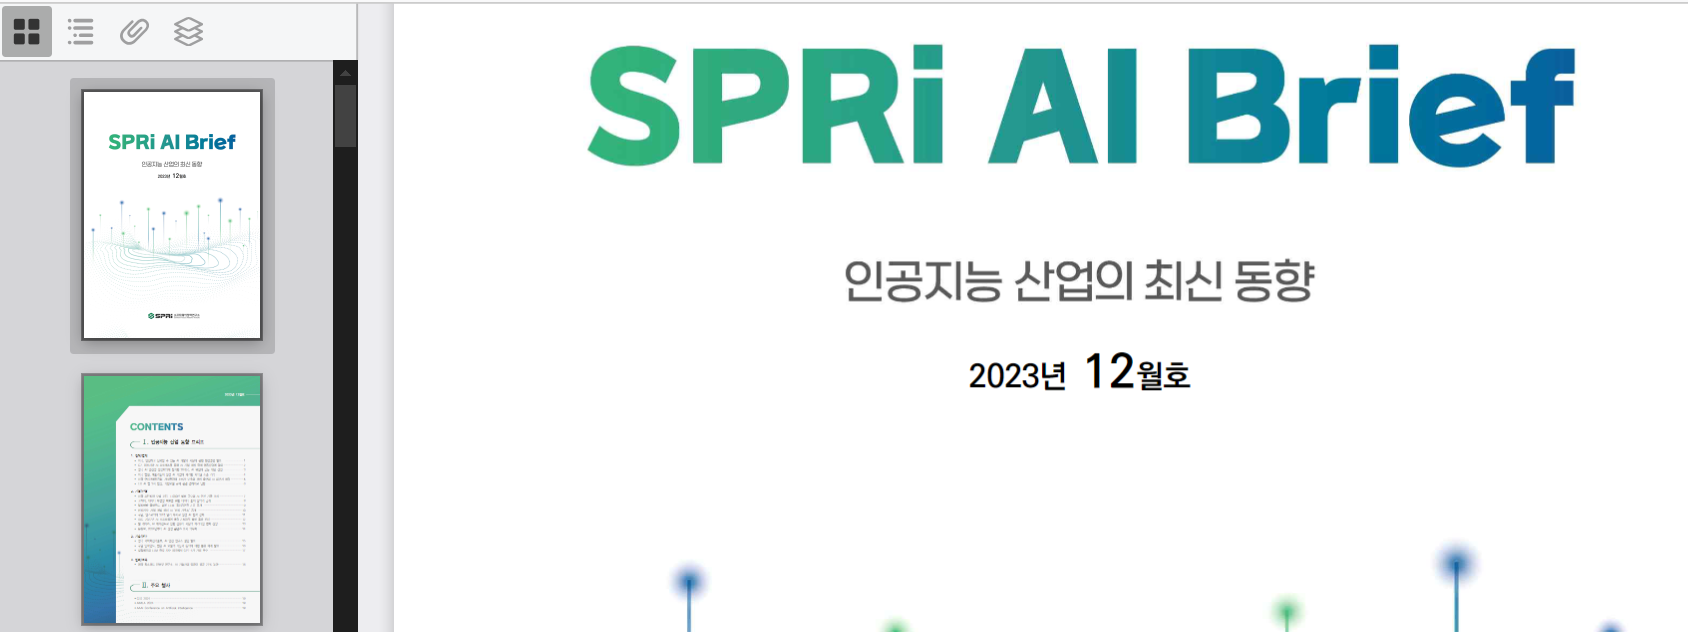

In [3]:
# 시작, 목차, 끝 페이지 제외
documents = documents[3:-1]

# 문서의 페이지수
len(documents)

19

> metadata 처리 

In [4]:
documents[0].metadata

{'source': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'file_path': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'page': 3,
 'total_pages': 23,
 'Author': 'dj',
 'Creator': 'Hwp 2018 10.0.0.13462',
 'Producer': 'Hancom PDF 1.3.0.542',
 'CreationDate': "D:20231208132838+09'00'",
 'ModDate': "D:20231208132838+09'00'",
 'PDFVersion': '1.4'}

In [5]:
# metadata 설정(filename 이 존재해야 함)
for doc in documents:
    doc.metadata["source"] = f"file path: {doc.metadata["file_path"]} & page no: {doc.metadata['page']}"


In [6]:
documents[0].metadata

{'source': 'file path: ./data/SPRI_AI_Brief_2023년12월호_F.pdf & page no: 3',
 'file_path': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'page': 3,
 'total_pages': 23,
 'Author': 'dj',
 'Creator': 'Hwp 2018 10.0.0.13462',
 'Producer': 'Hancom PDF 1.3.0.542',
 'CreationDate': "D:20231208132838+09'00'",
 'ModDate': "D:20231208132838+09'00'",
 'PDFVersion': '1.4'}

> page_content 확인 

In [7]:
print(documents[0].page_content[:300])

1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육
미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표
KEY Contents
n 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고
광범위한 행정 조치를 명시
n 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자
보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함
£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진
n 미국 바


### 평가 데이터셋

#### [문장을 생성하는 LLM](https://platform.openai.com/docs/models)

In [8]:
from dotenv import load_dotenv 

# .env 파일에 있는 데이터를 환경변수에 등록해주는 함수 
load_dotenv()

True

In [9]:
# Langchain LLM 객체를 ragas가 인식할 수 있게 변형
# Wrapper -> 감싸다. 또는 형변환 된다...
from ragas.llms import LangchainLLMWrapper
# Langchain에서 인식할 수 있는 OpenaAI LLM 객체
from langchain_openai import ChatOpenAI

# 문장을 생성하는 LLM -> 질문 & 답변 생성을 목적으로...
generator_llm = LangchainLLMWrapper(ChatOpenAI(
    model="gpt-4o-mini"
))

#### [Embedding model](https://platform.openai.com/docs/guides/embeddings/embedding-models#embedding-models)

In [10]:
# Langchain Embedding model를 ragas가 인식할 수 있게 변형
from ragas.embeddings import LangchainEmbeddingsWrapper
# Langchain에서 인식할 수 있는 OpenaAI Embedding model 객체
from langchain_openai import OpenAIEmbeddings

# Embedding model -> 문장을 벡터로 변환하는 모델...
generator_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small"))

C:\Users\Playdata\AppData\Local\Temp\ipykernel_7600\2777670376.py:7: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = LangchainEmbeddingsWrapper(


#### 페르소나 정의(중요)
> 어떤 질문/답변 쌍을 만들지 정의함 

In [11]:
from ragas.testset.persona import Persona

personas = [
    Persona(
        name="AI Specialist",
        role_description=""""
        A professional who evaluates whether the responses generated by large language models (LLMs) are logically coherent and ethically sound.
        """,
    ),
]

#### 학습용 데이터를 만드는 객체

In [12]:
from ragas.testset import TestsetGenerator

# 학습용 데이터를 만드는 객체
generator = TestsetGenerator(
    llm=generator_llm, embedding_model=generator_embeddings, 
    persona_list=personas
)

In [13]:
from ragas.testset.transforms.extractors.llm_based import NERExtractor, SummaryExtractor, TitleExtractor

# transforms = [SummaryExtractor(), NERExtractor(), TitleExtractor()]
transforms = [NERExtractor()]

In [14]:
from ragas.testset.synthesizers.single_hop.specific import (
    SingleHopSpecificQuerySynthesizer
)

distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 1.0),
]

for query, _ in distribution:
    prompts = await query.adapt_prompts("korean", llm=generator_llm)
    query.set_prompts(**prompts)

#### 평가 데이터셋 생성

In [15]:
dataset = generator.generate_with_langchain_docs(
    documents[:],
    testset_size=10, # 총 몇개의 질문/답변 쌍을 만들지
    transforms=transforms,
    query_distribution=distribution,
)

Applying NERExtractor:   0%|          | 0/19 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

#### 생성된 데이터셋 확인

In [16]:
eval_dataset = dataset.to_evaluation_dataset()

In [17]:
print("Query:", eval_dataset[0].user_input)
print("Reference:", eval_dataset[0].reference)

Query: 행정명령에 따르면 안전하고 신뢰할 수 있는 AI 개발을 위해 어떤 주요 조치가 포함되었나요?
Reference: 행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제협력 등을 골자로 하고 있습니다.


In [18]:
# 생성된 테스트셋을 pandas DataFrame으로 변환
test_df = eval_dataset.to_pandas()
test_df.shape

(10, 3)

In [19]:
test_df.head(2)

,user_input,reference_contexts,reference
0,행정명령에 따르면 안전하고 신뢰할 수 있는 AI 개발을 위해 어떤 주요 조치가 포함...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...","행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,프랑스는 G7의 AI 국제 행동강령에 어떤 역할을 하고 있나요?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...","프랑스는 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI ..."


#### 저장 

In [ ]:
test_df.to_csv("./data/evaluation_ragas.csv", index=False, header=True)